## Augmented Binary Encoding

Sensor count: $ 2 + 4 + 8 + ...$


010000
000001

                > 010001

                000011        010011

                > 010010

010000         010100         010110
000100         110000         110010        110110
001000         000110         110100
100000         100010         100110

                > 100100

                001100         101100

                > 101000

001000
100000


## Redundant Binary Encoding

Sensor count: $ 2 + 2 + 2 + ... $

> 0101

> 0110



> 1001

> 1010


## Non-redundant Binary Encoding

Sensor count: $1 + 1 + 1 + ...$

Saved image successfully


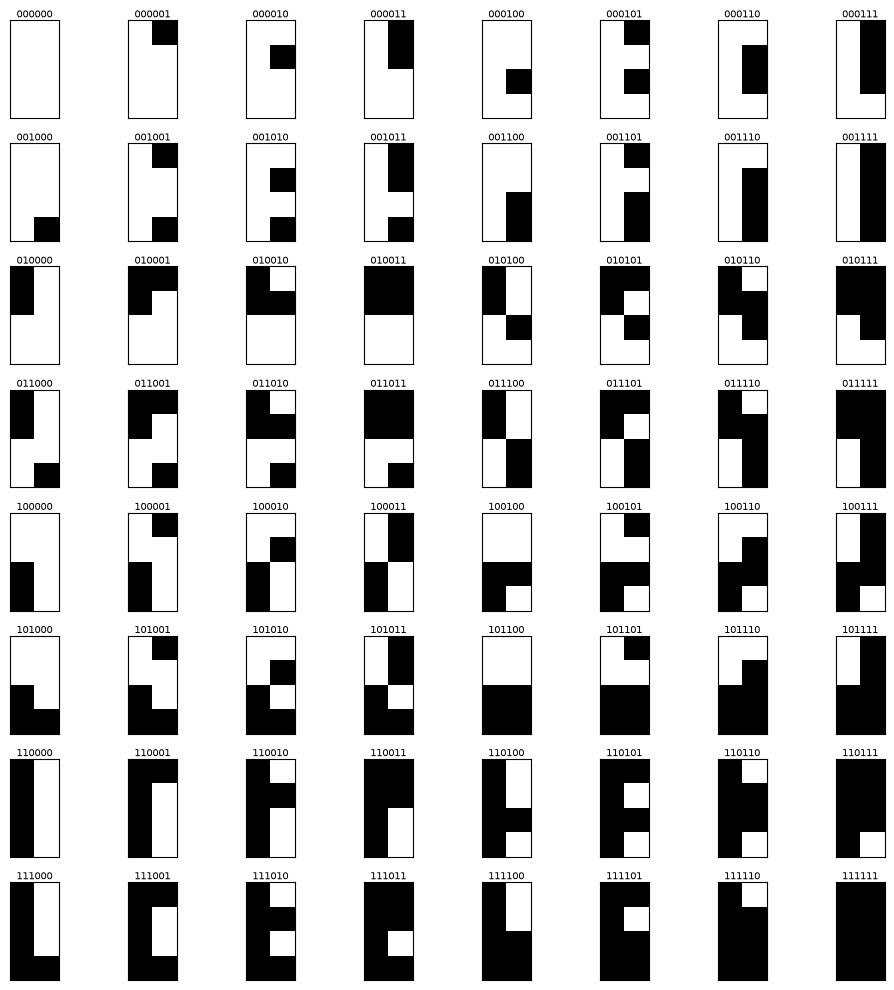

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Create figure
fig, axes = plt.subplots(8, 8, figsize=(10, 10))

for val in range(64):
    row_idx = val // 8
    col_idx = val % 8
    ax = axes[row_idx, col_idx]
    
    # Create 4x2 array (4 rows, 2 columns) initialized to light (e.g. 1.0 for white)
    # Note: array shape is (rows, cols) = (4, 2)
    # y is row index (0..3), x is col index (0..1)
    grid = np.ones((4, 2))
    
    # Check bit masks
    if val & 0b010000:
        grid[0, 0] = 0.0 # dark
        grid[1, 0] = 0.0 # dark
    if val & 0b100000:
        grid[2, 0] = 0.0
        grid[3, 0] = 0.0
        
    if val & 0b000001:
        grid[0, 1] = 0.0
    if val & 0b000010:
        grid[1, 1] = 0.0
    if val & 0b000100:
        grid[2, 1] = 0.0
    if val & 0b001000:
        grid[3, 1] = 0.0

    ax.imshow(grid, cmap='gray', vmin=0, vmax=1, origin='upper')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f"{val:06b}", fontsize=7, pad=2)

plt.tight_layout()
# plt.savefig("binary_states.png", dpi=150)
print("Saved image successfully")

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Map 6-bit to 4-bit according to the user's instructions:
# 6-bit value: b5 b4 b3 b2 b1 b0
# b5 -> 4-bit bit 3 (0b1000)
# b4 -> 4-bit bit 2 (0b0100)
# b3 OR b1 -> 4-bit bit 1 (0b0010)
# b2 OR b0 -> 4-bit bit 0 (0b0001)

def six_to_four(v6):
    b0 = (v6 >> 0) & 1
    b1 = (v6 >> 1) & 1
    b2 = (v6 >> 2) & 1
    b3 = (v6 >> 3) & 1
    b4 = (v6 >> 4) & 1
    b5 = (v6 >> 5) & 1
    
    bit0 = b0 | b2
    bit1 = b1 | b3
    bit2 = b4
    bit3 = b5
    
    return (bit3 << 3) | (bit2 << 2) | (bit1 << 1) | bit0

mapping = {v4: [] for v4 in range(16)}
for v6 in range(64):
    v4 = six_to_four(v6)
    mapping[v4].append(v6)

for v4, v6_list in mapping.items():
    print(f"4-bit {v4:04b} ({v4:2d}): {len(v6_list)} items -> {[f'{v:06b}' for v in v6_list]}")

4-bit 0000 ( 0): 1 items -> ['000000']
4-bit 0001 ( 1): 3 items -> ['000001', '000100', '000101']
4-bit 0010 ( 2): 3 items -> ['000010', '001000', '001010']
4-bit 0011 ( 3): 9 items -> ['000011', '000110', '000111', '001001', '001011', '001100', '001101', '001110', '001111']
4-bit 0100 ( 4): 1 items -> ['010000']
4-bit 0101 ( 5): 3 items -> ['010001', '010100', '010101']
4-bit 0110 ( 6): 3 items -> ['010010', '011000', '011010']
4-bit 0111 ( 7): 9 items -> ['010011', '010110', '010111', '011001', '011011', '011100', '011101', '011110', '011111']
4-bit 1000 ( 8): 1 items -> ['100000']
4-bit 1001 ( 9): 3 items -> ['100001', '100100', '100101']
4-bit 1010 (10): 3 items -> ['100010', '101000', '101010']
4-bit 1011 (11): 9 items -> ['100011', '100110', '100111', '101001', '101011', '101100', '101101', '101110', '101111']
4-bit 1100 (12): 1 items -> ['110000']
4-bit 1101 (13): 3 items -> ['110001', '110100', '110101']
4-bit 1110 (14): 3 items -> ['110010', '111000', '111010']
4-bit 1111 (15)

In [3]:
import numpy as np
from scipy.ndimage import label

def get_6bit_grid(v6):
    grid = np.ones((4, 2))
    if v6 & 0b010000:  # Bit 4
        grid[0, 0] = 0.0
        grid[1, 0] = 0.0
    if v6 & 0b100000:  # Bit 5
        grid[2, 0] = 0.0
        grid[3, 0] = 0.0
    if v6 & 0b000001:  # Bit 0
        grid[0, 1] = 0.0
    if v6 & 0b000010:  # Bit 1
        grid[1, 1] = 0.0
    if v6 & 0b000100:  # Bit 2
        grid[2, 1] = 0.0
    if v6 & 0b001000:  # Bit 3
        grid[3, 1] = 0.0
    return grid

# 4-connectivity structure for grid:
# [[0, 1, 0],
#  [1, 1, 1],
#  [0, 1, 0]]
structure_4 = np.array([[0, 1, 0],
                        [1, 1, 1],
                        [0, 1, 0]])

green_list = []
blue_list = []
none_list = []

for v6 in range(64):
    grid = get_6bit_grid(v6)
    binary_black = (grid == 0.0).astype(int)
    
    labeled_array, num_features = label(binary_black, structure=structure_4)
    
    if num_features == 1:
        green_list.append(v6)
    elif num_features > 1:
        blue_list.append(v6)
    else:
        none_list.append(v6)

print(f"Single contiguous region (Green, {len(green_list)}): {[f'{v:06b}' for v in green_list]}")
print(f"Disjointed regions (Blue, {len(blue_list)}): {[f'{v:06b}' for v in blue_list]}")
print(f"No regions (None, {len(none_list)}): {[f'{v:06b}' for v in none_list]}")

Single contiguous region (Green, 42): ['000001', '000010', '000011', '000100', '000110', '000111', '001000', '001100', '001110', '001111', '010000', '010001', '010010', '010011', '010110', '010111', '011110', '011111', '100000', '100100', '100110', '100111', '101000', '101100', '101110', '101111', '110000', '110001', '110010', '110011', '110100', '110101', '110110', '110111', '111000', '111001', '111010', '111011', '111100', '111101', '111110', '111111']
Disjointed regions (Blue, 21): ['000101', '001001', '001010', '001011', '001101', '010100', '010101', '011000', '011001', '011010', '011011', '011100', '011101', '100001', '100010', '100011', '100101', '101001', '101010', '101011', '101101']
No regions (None, 1): ['000000']


In [4]:
def count_contiguous_regions(grid):
    black_mask = (grid == 0.0)
    visited = np.zeros_like(black_mask, dtype=bool)
    components = 0
    
    rows, cols = black_mask.shape
    for r in range(rows):
        for c in range(cols):
            if black_mask[r, c] and not visited[r, c]:
                components += 1
                queue = [(r, c)]
                visited[r, c] = True
                while queue:
                    curr_r, curr_c = queue.pop(0)
                    for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                        nr, nc = curr_r + dr, curr_c + dc
                        if 0 <= nr < rows and 0 <= nc < cols:
                            if black_mask[nr, nc] and not visited[nr, nc]:
                                visited[nr, nc] = True
                                queue.append((nr, nc))
    return components

# Compare scipy label with custom BFS
scipy_green = []
scipy_blue = []
bfs_green = []
bfs_blue = []

for v6 in range(64):
    grid = get_6bit_grid(v6)
    
    # scipy
    black_pixels = (grid == 0.0).astype(int)
    _, num_c_scipy = label(black_pixels, structure=structure_4)
    if num_c_scipy == 1: scipy_green.append(v6)
    elif num_c_scipy > 1: scipy_blue.append(v6)
    
    # BFS
    num_c_bfs = count_contiguous_regions(grid)
    if num_c_bfs == 1: bfs_green.append(v6)
    elif num_c_bfs > 1: bfs_blue.append(v6)

assert scipy_green == bfs_green
assert scipy_blue == bfs_blue
print("BFS custom logic perfectly matches scipy.ndimage.label!")

BFS custom logic perfectly matches scipy.ndimage.label!


Saved 16-row colored mapping grid successfully.


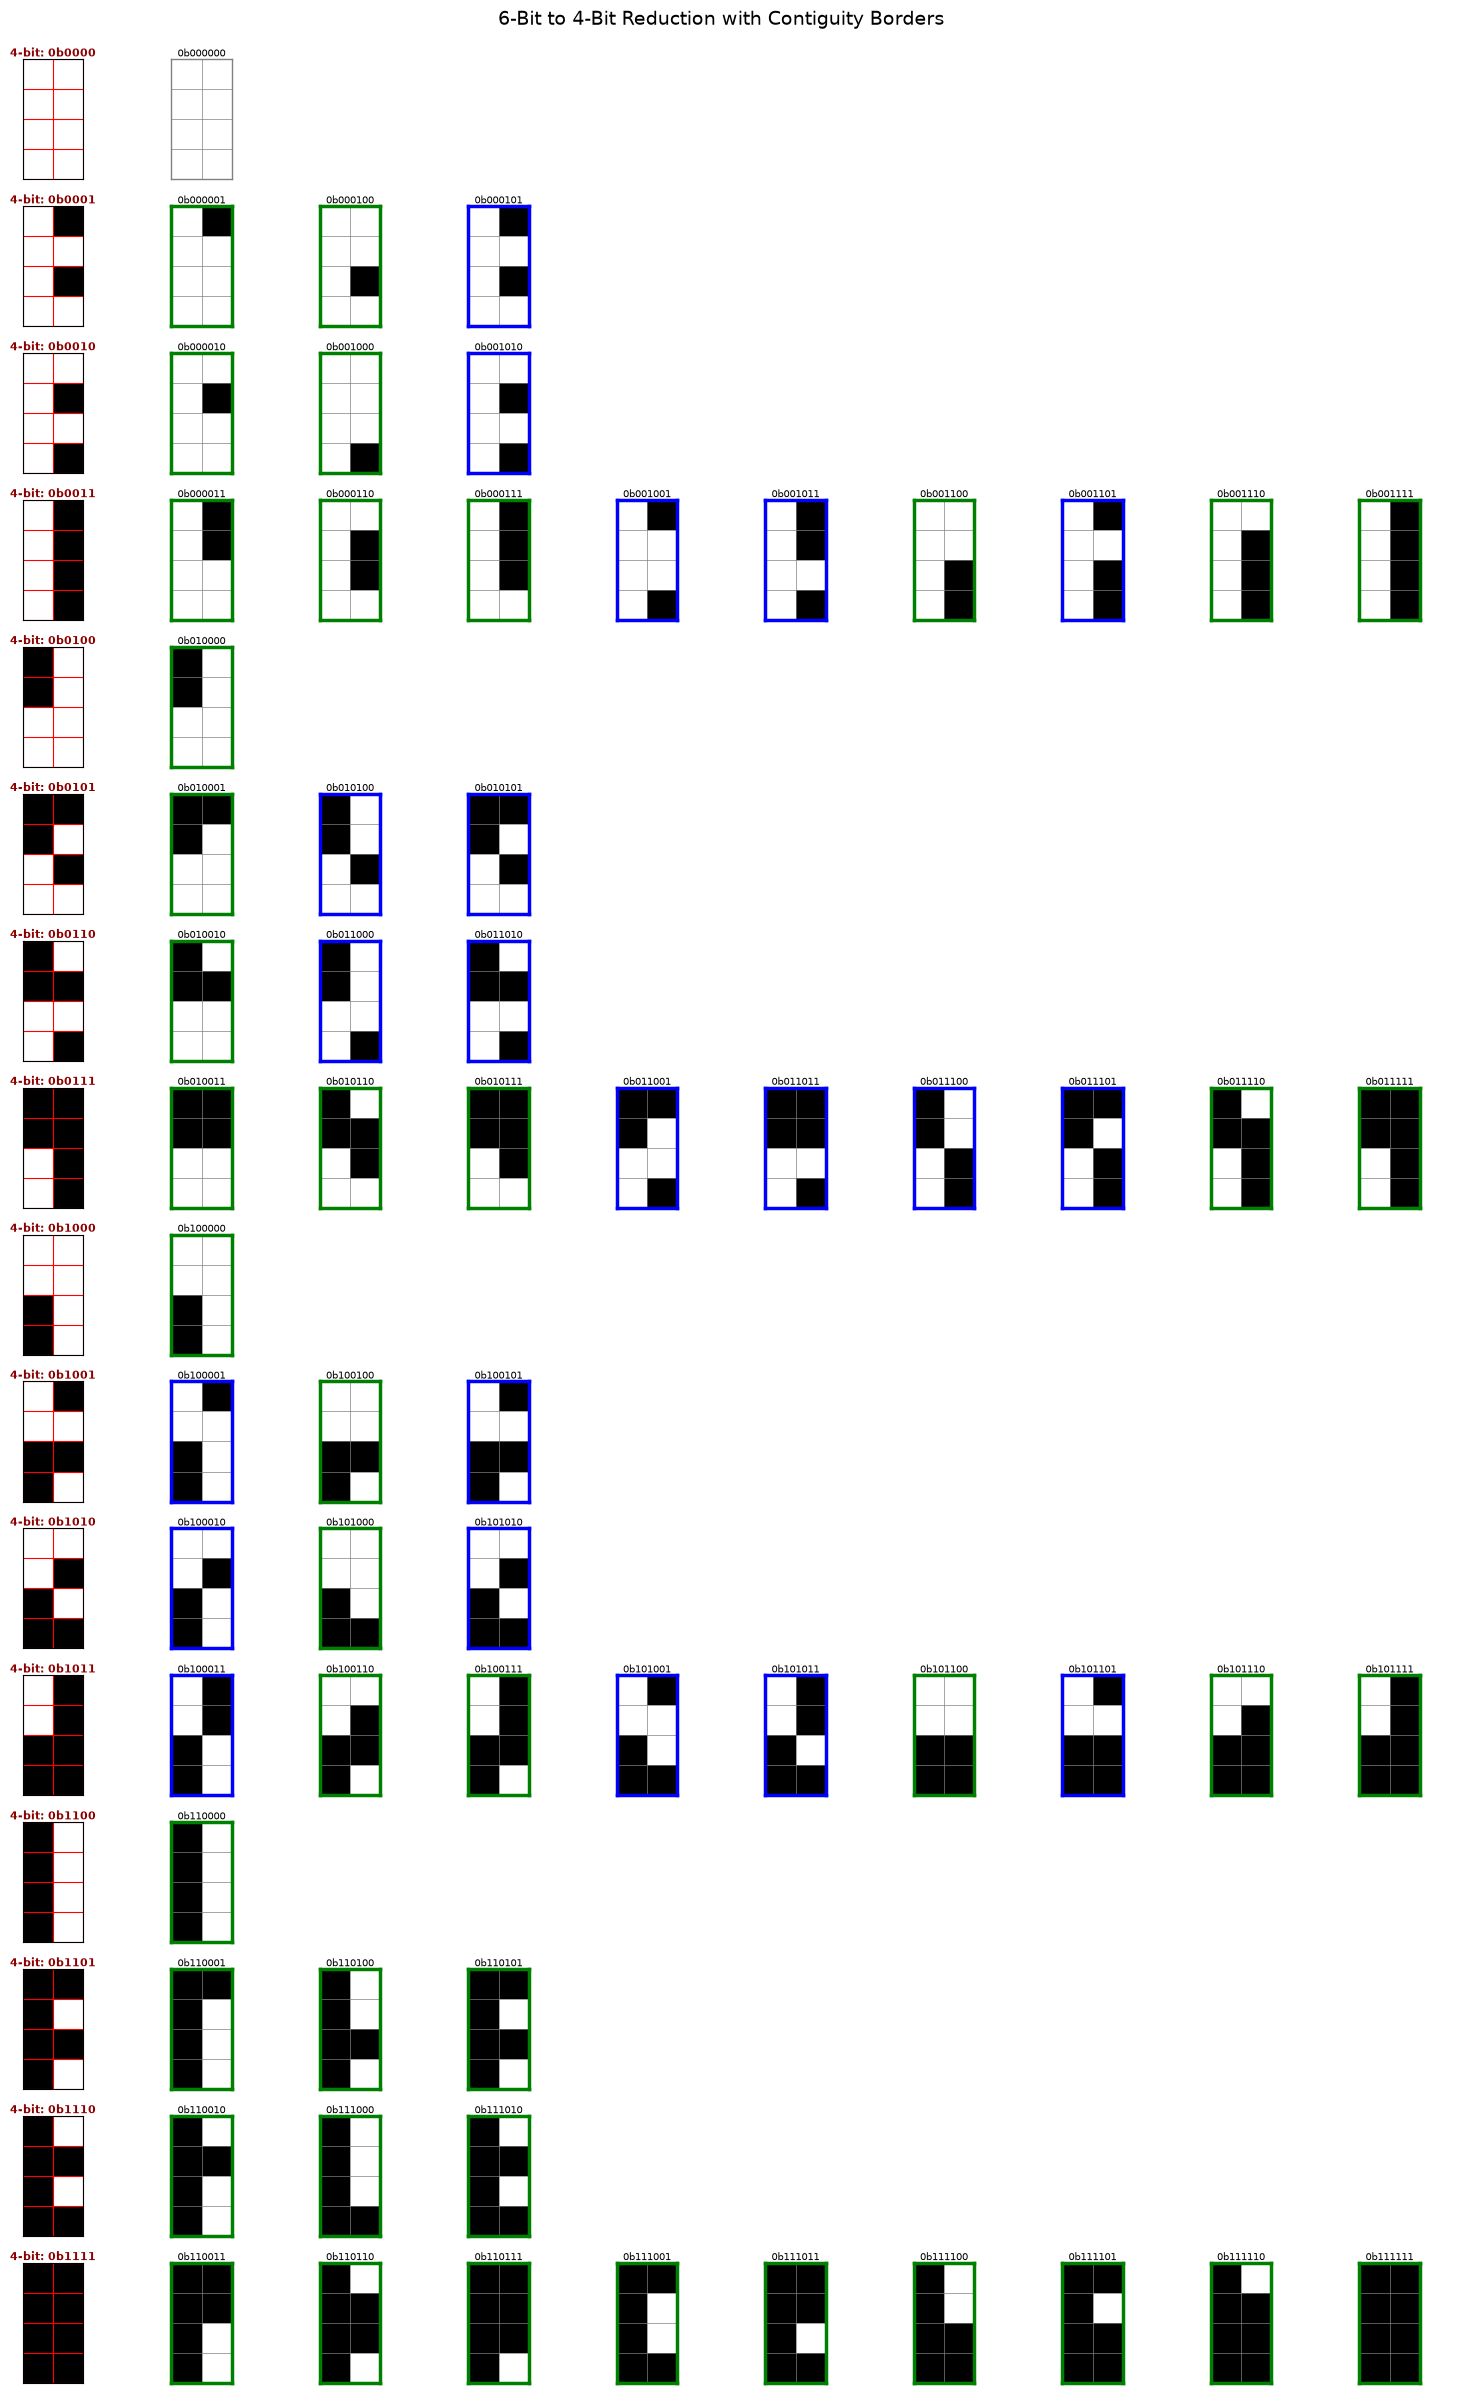

In [ ]:
def get_4bit_grid(v4):
    grid = np.ones((4, 2))
    if v4 & 0b0100:
        grid[0, 0] = 0.0
        grid[1, 0] = 0.0
    if v4 & 0b1000:
        grid[2, 0] = 0.0
        grid[3, 0] = 0.0
    if v4 & 0b0001:
        grid[0, 1] = 0.0
        grid[2, 1] = 0.0
    if v4 & 0b0010:
        grid[1, 1] = 0.0
        grid[3, 1] = 0.0
    return grid

def reduce_6_to_4(v6):
    b0 = (v6 >> 0) & 1
    b1 = (v6 >> 1) & 1
    b2 = (v6 >> 2) & 1
    b3 = (v6 >> 3) & 1
    b4 = (v6 >> 4) & 1
    b5 = (v6 >> 5) & 1
    return (b5 << 3) | (b4 << 2) | ((b1 | b3) << 1) | (b0 | b2)

mapping = {v4: [] for v4 in range(16)}
for v6 in range(64):
    v4 = reduce_6_to_4(v6)
    mapping[v4].append(v6)

max_cols = 10
fig, axes = plt.subplots(16, max_cols, figsize=(15, 24))

for row in range(16):
    v4 = row
    v6_matches = mapping[v4]
    
    # Col 0: 4-bit target
    ax = axes[row, 0]
    grid_4 = get_4bit_grid(v4)
    ax.imshow(grid_4, cmap='gray', vmin=0, vmax=1, origin='upper', extent=[0, 2, 4, 0])
    ax.set_xticks(np.arange(0, 3, 1))
    ax.set_yticks(np.arange(0, 5, 1))
    ax.grid(color='red', linestyle='-', linewidth=0.8)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.tick_params(length=0)
    ax.set_title(f"4-bit: 0b{v4:04b}", fontsize=8, color='darkred', weight='bold', pad=2)
    
    # Cols 1..9: 6-bit states with colored borders
    for col in range(1, max_cols):
        ax_sub = axes[row, col]
        v6_idx = col - 1
        if v6_idx < len(v6_matches):
            v6 = v6_matches[v6_idx]
            grid_6 = get_6bit_grid(v6)
            ax_sub.imshow(grid_6, cmap='gray', vmin=0, vmax=1, origin='upper', extent=[0, 2, 4, 0])
            ax_sub.set_xticks(np.arange(0, 3, 1))
            ax_sub.set_yticks(np.arange(0, 5, 1))
            ax_sub.grid(color='gray', linestyle='-', linewidth=0.5)
            ax_sub.set_xticklabels([])
            ax_sub.set_yticklabels([])
            ax_sub.tick_params(length=0)
            ax_sub.set_title(f"0b{v6:06b}", fontsize=7, pad=2)
            
            # Apply colored border based on connectivity
            num_components = count_contiguous_regions(grid_6)
            if num_components == 1:
                border_color = 'green'
                lw = 2.5
            elif num_components > 1:
                border_color = 'blue'
                lw = 2.5
            else:
                border_color = 'gray'
                lw = 1.0
                
            for spine in ax_sub.spines.values():
                spine.set_color(border_color)
                spine.set_linewidth(lw)
        else:
            ax_sub.axis('off')

plt.suptitle("6-Bit to 4-Bit Reduction with Contiguity Borders", fontsize=14, y=0.995)
plt.tight_layout()
# plt.savefig("16row_colored_mapping.png", dpi=150, bbox_inches='tight')
print("Saved 16-row colored mapping grid successfully.")

## Ambiguity Types for Augmented Binary Encoding

- Contiguous trigger ambiguity: single-bit, dual-bit (single layer), triple bit.
    - Two trigger sections that are not connected (not considering diagonals)
- Disjointed trigger ambiguity: dual-bit, triple bit, quad bit.


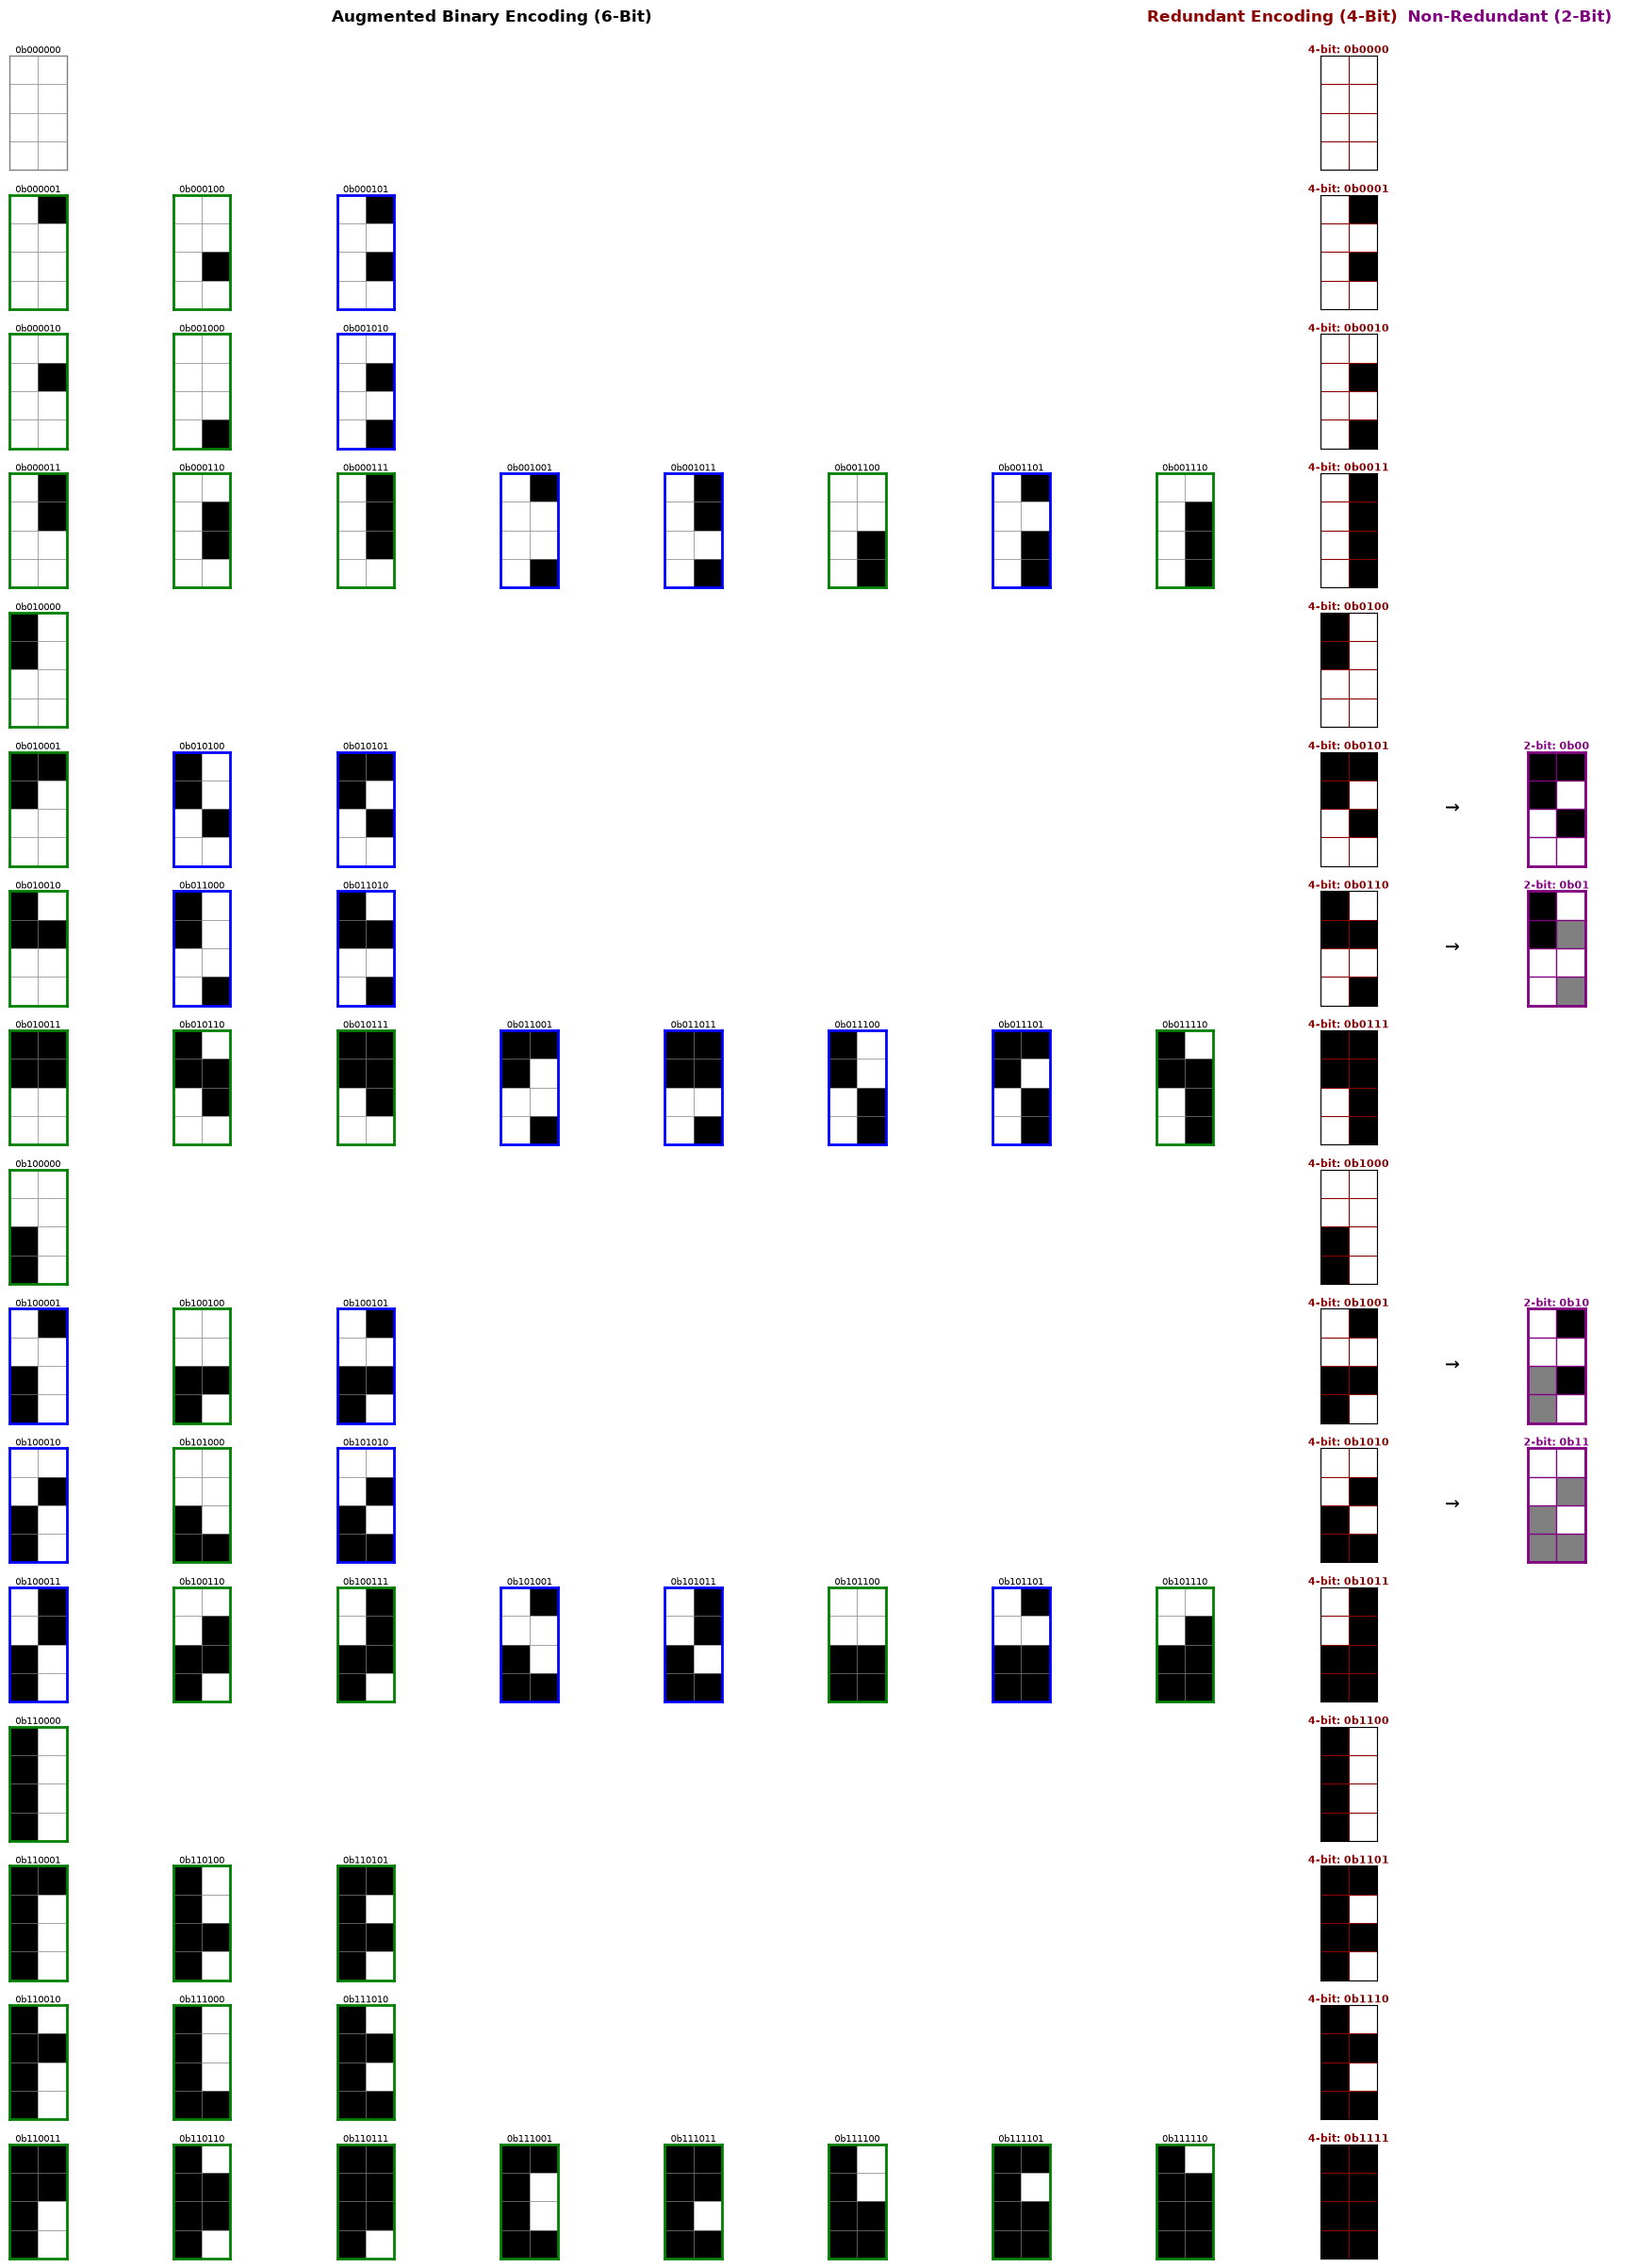

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Map of the 4 valid 4-bit states to (2-bit label, col1_color, col2_color)
VALID_2BIT_MAP = {
    0b0101: ("0b00", 0.0, 0.0),  # Image 1: Left Black, Right Black
    0b0110: ("0b01", 0.0, 0.5),  # Image 2: Left Black, Right Grey
    0b1001: ("0b10", 0.5, 0.0),  # Image 3: Left Grey,  Right Black
    0b1010: ("0b11", 0.5, 0.5),  # Image 4: Left Grey,  Right Grey
}

# Construct total layout: 16 rows x 11 columns
fig, axes = plt.subplots(16, 11, figsize=(18, 24), gridspec_kw={'width_ratios': [1]*8 + [1, 0.2, 1]})

for row in range(16):
    v4 = row
    v6_matches = mapping_6_to_4[v4]

    # --------------------------------------------------------------------------
    # SECTION 1: 6-Bit Augmented Binary Encoding (Cols 0..7)
    # --------------------------------------------------------------------------
    for col in range(8):
        ax_sub = axes[row, col]
        if col < len(v6_matches):
            v6 = v6_matches[col]
            grid_6 = get_6bit_grid(v6)
            ax_sub.imshow(grid_6, cmap='gray', vmin=0, vmax=1, origin='upper', extent=[0, 2, 4, 0])
            ax_sub.set_xticks(np.arange(0, 3, 1))
            ax_sub.set_yticks(np.arange(0, 5, 1))
            ax_sub.grid(color='gray', linestyle='-', linewidth=0.5)
            ax_sub.set_xticklabels([])
            ax_sub.set_yticklabels([])
            ax_sub.tick_params(length=0)
            ax_sub.set_title(f"0b{v6:06b}", fontsize=7, pad=2)

            # Apply contiguity border
            num_components = count_contiguous_regions(grid_6)
            if num_components == 1:
                border_color, lw = 'green', 2.0
            elif num_components > 1:
                border_color, lw = 'blue', 2.0
            else:
                border_color, lw = 'gray', 1.0

            for spine in ax_sub.spines.values():
                spine.set_color(border_color)
                spine.set_linewidth(lw)
        else:
            ax_sub.axis('off')

    # --------------------------------------------------------------------------
    # SECTION 2: 4-Bit Redundant Binary Encoding (Col 8)
    # --------------------------------------------------------------------------
    ax_4bit = axes[row, 8]
    grid_4 = get_4bit_grid(v4)
    ax_4bit.imshow(grid_4, cmap='gray', vmin=0, vmax=1, origin='upper', extent=[0, 2, 4, 0])
    ax_4bit.set_xticks(np.arange(0, 3, 1))
    ax_4bit.set_yticks(np.arange(0, 5, 1))
    ax_4bit.grid(color='darkred', linestyle='-', linewidth=0.8)
    ax_4bit.set_xticklabels([])
    ax_4bit.set_yticklabels([])
    ax_4bit.tick_params(length=0)
    ax_4bit.set_title(f"4-bit: 0b{v4:04b}", fontsize=8, color='darkred', weight='bold', pad=2)

    # --------------------------------------------------------------------------
    # SECTION 3: 2-Bit Non-Redundant Binary Encoding (Col 10) & Arrow (Col 9)
    # --------------------------------------------------------------------------
    ax_sep = axes[row, 9]
    ax_2bit = axes[row, 10]

    if v4 in VALID_2BIT_MAP:
        label_2bit, col1_color, col2_color = VALID_2BIT_MAP[v4]

        # Draw transition arrow
        ax_sep.axis('off')
        ax_sep.text(0.5, 0.5, r"$\rightarrow$", fontsize=14, ha='center', va='center')

        # Copy the 4-bit shape directly and apply column-specific fills
        grid_2 = np.ones_like(grid_4)
        
        # Left column active pixels (x=0)
        grid_2[:, 0] = np.where(grid_4[:, 0] == 0.0, col1_color, 1.0)
        # Right column active pixels (x=1)
        grid_2[:, 1] = np.where(grid_4[:, 1] == 0.0, col2_color, 1.0)

        ax_2bit.imshow(grid_2, cmap='gray', vmin=0, vmax=1, origin='upper', extent=[0, 2, 4, 0])
        ax_2bit.set_xticks(np.arange(0, 3, 1))
        ax_2bit.set_yticks(np.arange(0, 5, 1))
        ax_2bit.grid(color='purple', linestyle='-', linewidth=1.0)
        ax_2bit.set_xticklabels([])
        ax_2bit.set_yticklabels([])
        ax_2bit.tick_params(length=0)
        ax_2bit.set_title(f"2-bit: {label_2bit}", fontsize=8, color='purple', weight='bold', pad=2)

        for spine in ax_2bit.spines.values():
            spine.set_color('purple')
            spine.set_linewidth(2.0)
    else:
        # Invalid state: Leave completely empty with no figure
        ax_sep.axis('off')
        ax_2bit.axis('off')

# Section Headings
fig.text(0.32, 0.995, "Augmented Binary Encoding (6-Bit)", fontsize=12, weight='bold', ha='center')
fig.text(0.78, 0.995, "Redundant Encoding (4-Bit)", fontsize=12, color='darkred', weight='bold', ha='center')
fig.text(0.92, 0.995, "Non-Redundant (2-Bit)", fontsize=12, color='purple', weight='bold', ha='center')

plt.tight_layout()
plt.subplots_adjust(top=0.98)
# plt.savefig("pipeline_2bit_column_coloring.png", dpi=150, bbox_inches='tight')
plt.show()